# Solving a Non-Homogeneous ODE with PINNs in JAX

## Problem Statement
We aim to solve the following second-order non-homogeneous differential equation:
$$y'' + 2y' + y = 3\sqrt{x+1}e^{-x}$$

With initial conditions:
- $y(0) = 0$
- $y'(0) = 1$

The analytical solution is:
$$y(x) = \left[\frac{4}{5}(x+1)^{5/2} - 0.8 - x\right]e^{-x}$$

## Goal
- Define a Physics-Informed Neural Network (PINN) from scratch using JAX.
- Implement the ODE residual as a loss function using `jax.grad`.
- Train the model using the `optax` optimizer.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
import time
#from medical_constants import * # Optional if you have specific constants

# Force JAX to use CPU for this small example (optional)
import os
os.environ['XLA_FLAGS'] = '--xla_force_host_platform_device_count=1'

def exact_solution(x):
    term1 = 0.8 * (x + 1)**2.5
    term2 = -0.8
    term3 = -x
    return (term1 + term2 + term3) * jnp.exp(-x)

In [2]:
class FCN:
    @staticmethod
    def init_parameters(key, layer_sizes):
        keys = jax.random.split(key, len(layer_sizes)-1)
        parameters = []
        for k, m, n in zip(keys, layer_sizes[:-1], layer_sizes[1:]):
            W_key, b_key = jax.random.split(k)
            v = jnp.sqrt(1/m)
            W = jax.random.uniform(W_key, (n, m), minval=-v, maxval=v)
            b = jax.random.uniform(b_key, (n,), minval=-v, maxval=v)
            parameters.append((W, b))
        return parameters

    @staticmethod
    def forward(parameters, x):
        # x is a single input point of shape (1,)
        u = x
        for i, (W, b) in enumerate(parameters):
            u = W @ u + b
            if i < len(parameters) - 1:
                u = jnp.tanh(u)
        return u

In [3]:
def PINN_physics_loss(parameters, x, network):
    # x is a single point (1,)
    def u_fn(x_val):
        return network.forward(parameters, x_val.reshape(1,)).squeeze()

    x_val = x.squeeze()
    u = u_fn(x_val)

    # Compute gradients using autodiff
    u_x = jax.grad(u_fn)(x_val)
    u_xx = jax.grad(jax.grad(u_fn))(x_val)

    # RHS of the ODE: 3 * sqrt(x+1) * exp(-x)
    rhs = 3 * jnp.sqrt(x_val + 1) * jnp.exp(-x_val)

    # ODE: y'' + 2y' + y - rhs = 0
    residual = u_xx + 2*u_x + u - rhs
    return jnp.square(residual)

def PINN_boundary_loss(parameters, network):
    # Initial conditions at x=0
    x0 = jnp.array([0.0])

    def u_fn(x_val):
        return network.forward(parameters, x_val.reshape(1,)).squeeze()

    u0 = u_fn(x0)
    u0_x = jax.grad(u_fn)(x0.squeeze())

    # y(0) = 0, y'(0) = 1
    loss_y = jnp.square(u0 - 0.0)
    loss_y_x = jnp.square(u0_x - 1.0)
    return loss_y, loss_y_x

def total_loss_batch(parameters, x_physics_batch, network):
    # Batched physics loss
    p_loss = jax.vmap(PINN_physics_loss, in_axes=(None, 0, None))(parameters, x_physics_batch, network)
    mean_p_loss = jnp.mean(p_loss)

    # Boundary loss
    l_y, l_yx = PINN_boundary_loss(parameters, network)

    return 1e-3 * mean_p_loss + l_y + l_yx

In [4]:
from functools import partial

# We mark index 1 (optimiser) and index 4 (network) as static
# because they are Python objects/functions, not JAX arrays.
@partial(jax.jit, static_argnums=(1, 4))
def train_step(opt_state, optimiser, parameters, x_physics_batch, network):

    # Define the loss and gradient function
    # argnums=0 ensures we take the gradient with respect to 'parameters'
    loss_val, grads = jax.value_and_grad(total_loss_batch, argnums=0)(
        parameters, x_physics_batch, network)

    # Use the optimiser to calculate updates
    updates, opt_state = optimiser.update(grads, opt_state, parameters)

    # Apply the updates to the parameters
    parameters = optax.apply_updates(parameters, updates)

    return loss_val, opt_state, parameters

<>:35: SyntaxWarning: invalid escape sequence '\s'
<>:35: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-2991407412.py:35: SyntaxWarning: invalid escape sequence '\s'
  plt.title("PINN Solution for $y'' + 2y' + y = 3\sqrt{x+1}e^{-x}$")


Step 0, Loss: 1.306114
Step 5000, Loss: 0.000035
Step 10000, Loss: 0.000002
Total training time: 37.94s


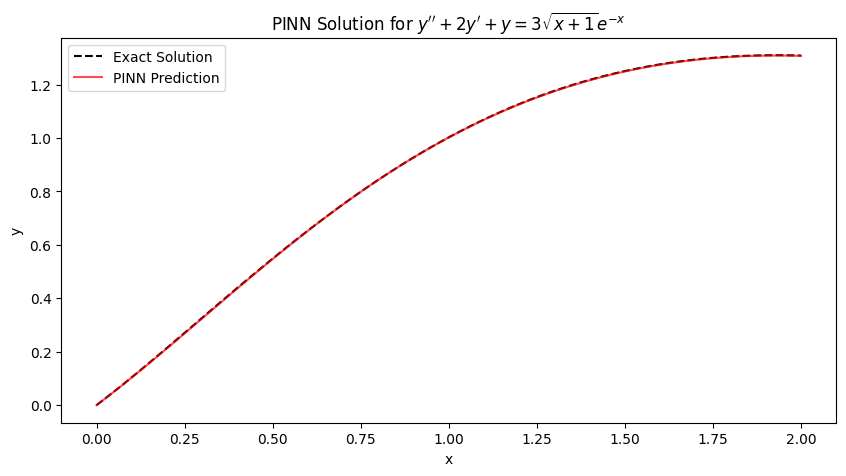

In [6]:
key = jax.random.PRNGKey(0)
layer_sizes = [1, 20, 20, 20, 1]

# 1. Initialize Network
network = FCN()

# 2. Initialize Parameters
params = FCN.init_parameters(key, layer_sizes)

# 3. Initialize Optimizer
learning_rate = 1e-3
optimiser = optax.adam(learning_rate)
opt_state = optimiser.init(params)

# 4. Initialize Physics Loss Data
x_physics_batch = jax.random.uniform(key, (1000, 1), minval=0.0, maxval=2.0)

start_time = time.time()
for i in range(10001):
    loss_val, opt_state, params = train_step(opt_state, optimiser, params, x_physics_batch, network)

    if i % 5000 == 0:
        print(f"Step {i}, Loss: {loss_val:.6f}")

print(f"Total training time: {time.time() - start_time:.2f}s")

# Plot Results
x_test = jnp.linspace(0, 2, 100).reshape(-1, 1)
u_exact = exact_solution(x_test)
u_pinn = jax.vmap(network.forward, in_axes=(None, 0))(params, x_test)

plt.figure(figsize=(10, 5))
plt.plot(x_test, u_exact, label="Exact Solution", color='black', linestyle='--')
plt.plot(x_test, u_pinn, label="PINN Prediction", color='red', alpha=0.7)
plt.title("PINN Solution for $y'' + 2y' + y = 3\sqrt{x+1}e^{-x}$")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()